<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_Deep-Learning-with-Python/blob/main/scripts/Fully_Convolutional_Network_FCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9096 - loss: 0.6133
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9897 - loss: 0.3492
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9927 - loss: 0.0897
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


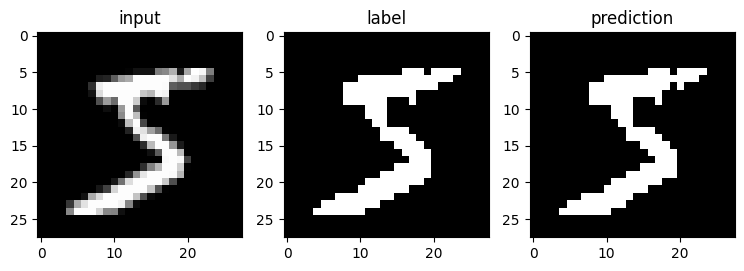

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# 1. MNIST 샘플 로드 (1000장만 사용)
(x_train, _), _ = keras.datasets.mnist.load_data()
X = (x_train[:1000] / 255.0).astype("float32")[..., np.newaxis]  # (1000, 28, 28, 1)

# 2. 픽셀별 라벨 생성: 숫자가 있는 픽셀=1, 배경=0
y = (X > 0.3).astype("int32")  # (1000, 28, 28, 1)

# 3. FCN 모델 — 끝이 1x1 Conv
inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(16, 3, padding="same", activation="relu")(inputs)
x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)  # 픽셀별 확률 출력
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X, y, epochs=3, batch_size=32)

# 4. 한 장 예측해보기
pred = model.predict(X[:1])[0, ..., 0]       # (28, 28) 각 픽셀의 확률
mask = (pred > 0.5).astype("uint8")          # 픽셀별 분류 결과

# 5. 시각화: 입력 / 정답 / 예측
plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1); plt.imshow(X[0, ..., 0], cmap="gray"); plt.title("input")
plt.subplot(1, 3, 2); plt.imshow(y[0, ..., 0], cmap="gray"); plt.title("label")
plt.subplot(1, 3, 3); plt.imshow(mask, cmap="gray"); plt.title("prediction")
plt.show()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,489 (326.13 KB)

 Trainable params: 83,489 (326.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 760ms/step - accuracy: 0.9726 - loss: 0.1577 - val_accuracy: 0.9921 - val_loss: 0.0196
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 746ms/step - accuracy: 0.9937 - loss: 0.0156 - val_accuracy: 0.9950 - val_loss: 0.0118
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 82s 748ms/step - accuracy: 0.9955 - loss: 0.0110 - val_accuracy: 0.9962 - val_loss: 0.0093
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 83s 759ms/step - accuracy: 0.9962 - loss: 0.0092 - val_accuracy: 0.9962 - val_loss: 0.0092
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 765ms/step - accuracy: 0.9965 - loss: 0.0085 - val_accuracy: 0.9971 - val_loss: 0.0072
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


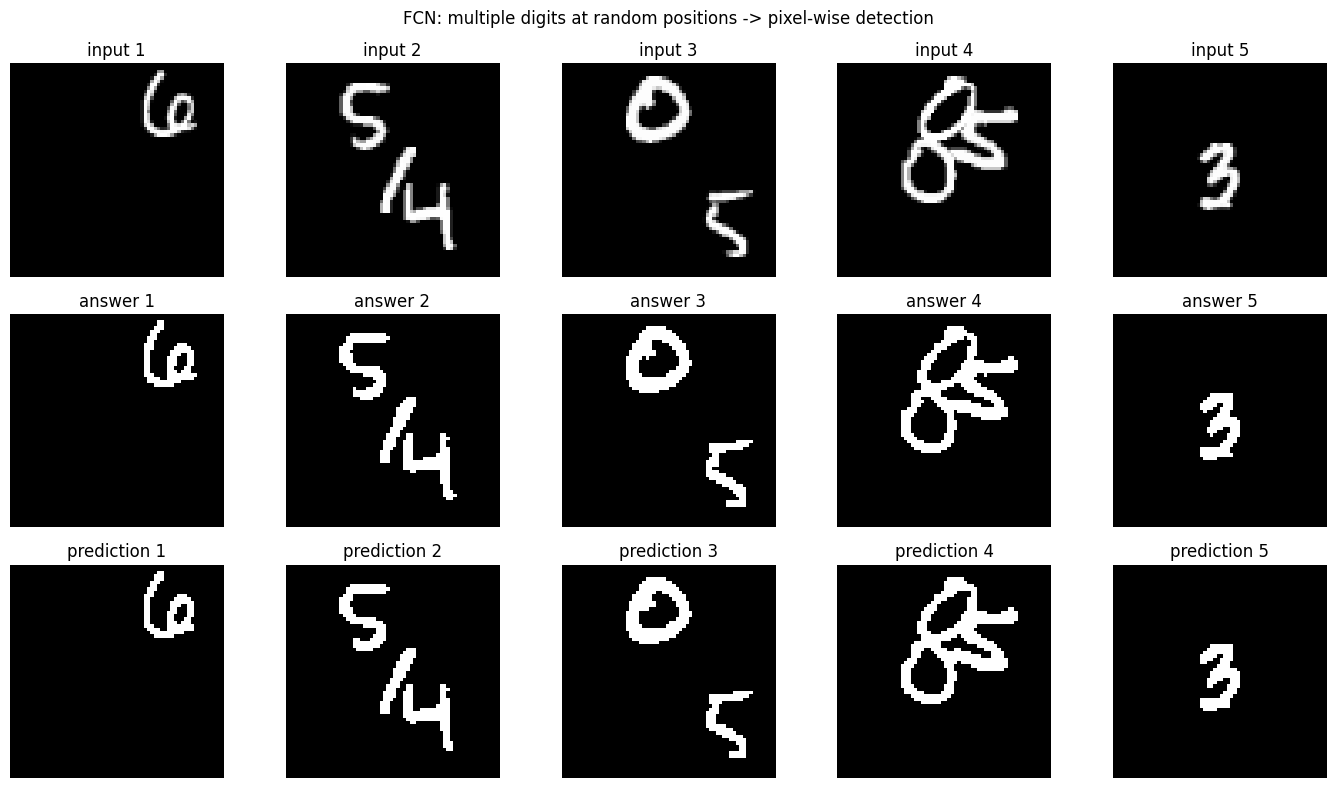

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# ---------------------------------------------------------
# 1. 데이터 생성: 64x64 캔버스에 MNIST 숫자 1~3개 랜덤 배치
# ---------------------------------------------------------
(x_all, _), _ = keras.datasets.mnist.load_data()
x_all = (x_all / 255.0).astype("float32")

CANVAS = 64
N_TRAIN, N_TEST = 2000, 5
rng = np.random.default_rng(42)

def make_sample():
    canvas = np.zeros((CANVAS, CANVAS), dtype="float32")
    mask = np.zeros((CANVAS, CANVAS), dtype="float32")
    n_digits = rng.integers(1, 4)  # 1~3개
    for _ in range(n_digits):
        d = x_all[rng.integers(len(x_all))]          # 28x28 숫자
        x0 = rng.integers(0, CANVAS - 28)
        y0 = rng.integers(0, CANVAS - 28)
        region = canvas[x0:x0+28, y0:y0+28]
        canvas[x0:x0+28, y0:y0+28] = np.maximum(region, d)  # 겹치면 밝은 쪽
        mask[x0:x0+28, y0:y0+28] = np.maximum(
            mask[x0:x0+28, y0:y0+28], (d > 0.3).astype("float32"))
    return canvas, mask

def make_dataset(n):
    X = np.zeros((n, CANVAS, CANVAS, 1), dtype="float32")
    Y = np.zeros((n, CANVAS, CANVAS, 1), dtype="float32")
    for i in range(n):
        X[i, ..., 0], Y[i, ..., 0] = make_sample()
    return X, Y

X_train, Y_train = make_dataset(N_TRAIN)
X_test, Y_test = make_dataset(N_TEST)

# ---------------------------------------------------------
# 2. FCN 모델: Flatten/Dense 없이 Conv + 1x1 Conv만 사용
# ---------------------------------------------------------
inputs = keras.Input(shape=(CANVAS, CANVAS, 1))
x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)                       # 64 -> 32
x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.UpSampling2D()(x)                       # 32 -> 64
x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)  # 1x1 Conv = 픽셀별 FC

model = keras.Model(inputs, outputs)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

# ---------------------------------------------------------
# 3. 학습
# ---------------------------------------------------------
model.fit(X_train, Y_train, epochs=5, batch_size=32,
          validation_split=0.1, verbose=1)

# ---------------------------------------------------------
# 4. 시각화: 원본 5개 / 정답 마스크 / 예측 결과
# ---------------------------------------------------------
preds = model.predict(X_test)

fig, axes = plt.subplots(3, N_TEST, figsize=(14, 8))
for i in range(N_TEST):
    axes[0, i].imshow(X_test[i, ..., 0], cmap="gray")
    axes[0, i].set_title(f"input {i+1}")
    axes[1, i].imshow(Y_test[i, ..., 0], cmap="gray")
    axes[1, i].set_title(f"answer {i+1}")
    axes[2, i].imshow(preds[i, ..., 0] > 0.5, cmap="gray")
    axes[2, i].set_title(f"prediction {i+1}")
for ax in axes.flat:
    ax.axis("off")

axes[0, 0].set_ylabel("input", rotation=0, labelpad=40, va="center")
axes[1, 0].set_ylabel("answer", rotation=0, labelpad=40, va="center")
axes[2, 0].set_ylabel("prediction", rotation=0, labelpad=40, va="center")

plt.suptitle("FCN: multiple digits at random positions -> pixel-wise detection")
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


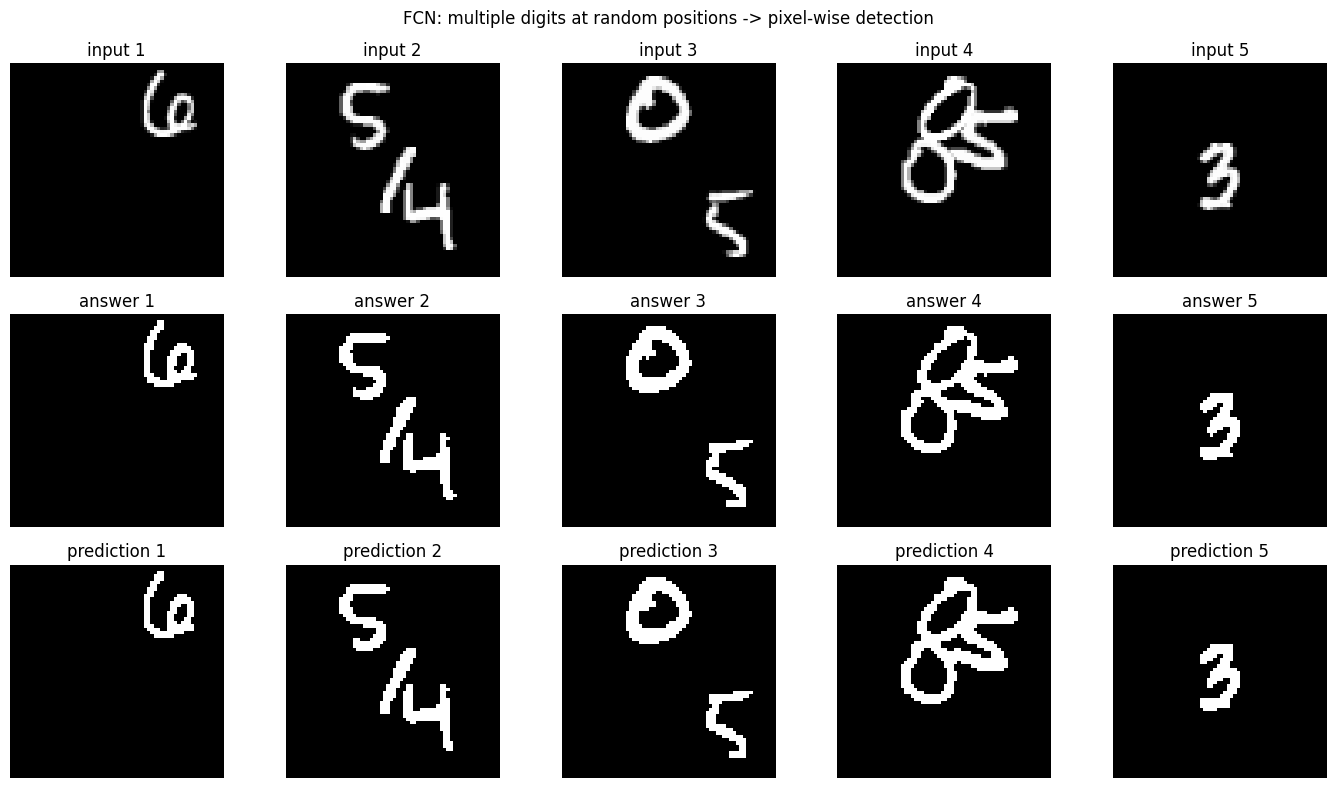

In [3]:
# ---------------------------------------------------------
# 4. 시각화: 원본 5개 / 정답 마스크 / 예측 결과
# ---------------------------------------------------------
preds = model.predict(X_test)

fig, axes = plt.subplots(3, N_TEST, figsize=(14, 8))
for i in range(N_TEST):
    axes[0, i].imshow(X_test[i, ..., 0], cmap="gray")
    axes[0, i].set_title(f"input {i+1}")
    axes[1, i].imshow(Y_test[i, ..., 0], cmap="gray")
    axes[1, i].set_title(f"answer {i+1}")
    axes[2, i].imshow(preds[i, ..., 0] > 0.5, cmap="gray")
    axes[2, i].set_title(f"prediction {i+1}")
for ax in axes.flat:
    ax.axis("off")

axes[0, 0].set_ylabel("input", rotation=0, labelpad=40, va="center")
axes[1, 0].set_ylabel("answer", rotation=0, labelpad=40, va="center")
axes[2, 0].set_ylabel("prediction", rotation=0, labelpad=40, va="center")

plt.suptitle("FCN: multiple digits at random positions -> pixel-wise detection")
plt.tight_layout()
plt.show()